# 🌍 World Happiness Report Analysis

**목적:** 세계 행복 지수 데이터를 분석하여 행복에 영향을 미치는 요인을 탐색하고, 회귀 모델로 행복 점수를 예측합니다.

**데이터:** World Happiness Report (2015–2022)

**분석 순서:**
1. 데이터 불러오기 및 전처리
2. 탐색적 데이터 분석 (EDA)
3. 상관관계 분석
4. 머신러닝 모델링 (회귀)
5. 결과 해석 및 인사이트

---

## 0. 라이브러리 및 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## 1. 데이터 불러오기 및 전처리

> 실제 데이터는 [Kaggle - World Happiness Report](https://www.kaggle.com/datasets/unsdsn/world-happiness) 에서 다운로드할 수 있습니다.  
> 여기서는 재현 가능한 샘플 데이터를 생성합니다.

In [2]:
np.random.seed(42)

# 대표 국가 목록
countries = [
    'Finland', 'Denmark', 'Iceland', 'Switzerland', 'Netherlands',
    'Norway', 'Sweden', 'Luxembourg', 'New Zealand', 'Austria',
    'Australia', 'Ireland', 'Germany', 'Canada', 'United States',
    'United Kingdom', 'Czech Republic', 'Belgium', 'France', 'Mexico',
    'Brazil', 'Argentina', 'Japan', 'South Korea', 'Singapore',
    'China', 'Thailand', 'India', 'Philippines', 'Indonesia',
    'Nigeria', 'Ghana', 'Kenya', 'Ethiopia', 'Zimbabwe'
]

regions = {
    'Finland': 'Western Europe', 'Denmark': 'Western Europe', 'Iceland': 'Western Europe',
    'Switzerland': 'Western Europe', 'Netherlands': 'Western Europe', 'Norway': 'Western Europe',
    'Sweden': 'Western Europe', 'Luxembourg': 'Western Europe', 'Austria': 'Western Europe',
    'Germany': 'Western Europe', 'Belgium': 'Western Europe', 'France': 'Western Europe',
    'New Zealand': 'ANZ', 'Australia': 'ANZ', 'Ireland': 'Western Europe',
    'Canada': 'North America', 'United States': 'North America', 'United Kingdom': 'Western Europe',
    'Czech Republic': 'Central Eastern Europe', 'Mexico': 'Latin America',
    'Brazil': 'Latin America', 'Argentina': 'Latin America',
    'Japan': 'East Asia', 'South Korea': 'East Asia', 'Singapore': 'Southeast Asia',
    'China': 'East Asia', 'Thailand': 'Southeast Asia', 'India': 'South Asia',
    'Philippines': 'Southeast Asia', 'Indonesia': 'Southeast Asia',
    'Nigeria': 'Sub-Saharan Africa', 'Ghana': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa', 'Ethiopia': 'Sub-Saharan Africa', 'Zimbabwe': 'Sub-Saharan Africa'
}

n = len(countries)

# 각 피처를 상관 구조와 함께 생성
gdp_log           = np.random.uniform(8.5, 11.5, n)
social_support    = np.clip(gdp_log / 11.5 * 0.7 + np.random.normal(0.1, 0.08, n), 0.3, 1.0)
healthy_life_exp  = np.clip(gdp_log / 11.5 * 40 + 40 + np.random.normal(0, 3, n), 50, 78)
freedom           = np.clip(np.random.uniform(0.3, 0.95, n), 0, 1)
generosity        = np.clip(np.random.normal(0.1, 0.15, n), -0.3, 0.6)
corruption        = np.clip(np.random.uniform(0.05, 0.85, n), 0, 1)

# 행복 점수 = 가중합 + 노이즈
happiness_score = (
    1.8 * (gdp_log - gdp_log.min()) / (gdp_log.max() - gdp_log.min()) +
    1.5 * social_support +
    0.8 * (healthy_life_exp - 50) / 28 +
    0.7 * freedom +
    0.3 * generosity -
    0.4 * corruption +
    np.random.normal(3.8, 0.2, n)
)
happiness_score = np.clip(happiness_score, 2.5, 8.0)

df = pd.DataFrame({
    'Country': countries,
    'Region': [regions[c] for c in countries],
    'Happiness_Score': happiness_score.round(3),
    'GDP_per_Capita': gdp_log.round(3),
    'Social_Support': social_support.round(3),
    'Healthy_Life_Expectancy': healthy_life_exp.round(2),
    'Freedom': freedom.round(3),
    'Generosity': generosity.round(3),
    'Corruption_Perception': corruption.round(3)
})

df.head(10)

,Country,Region,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception
0,Finland,Western Europe,6.563,9.624,0.638,70.78,0.859,0.188,0.620
1,Denmark,Western Europe,7.819,11.352,0.867,78.00,0.305,0.429,0.240
2,Iceland,Western Europe,7.570,10.696,0.774,78.00,0.632,-0.049,0.310
3,Switzerland,Western Europe,6.913,10.296,0.676,72.70,0.571,0.015,0.647
4,Netherlands,Western Europe,5.551,8.968,0.564,70.97,0.444,0.115,0.570
5,Norway,Western Europe,5.490,8.968,0.633,74.11,0.378,0.024,0.729
6,Sweden,Western Europe,5.384,8.674,0.585,72.56,0.519,-0.133,0.576
7,Luxembourg,Western Europe,7.978,11.099,0.775,78.00,0.913,0.110,0.505
8,New Zealand,ANZ,7.039,10.303,0.709,76.85,0.510,-0.059,0.125
9,Austria,Western Europe,7.556,10.624,0.778,78.00,0.637,0.171,0.344


In [3]:
print('=== 데이터 기본 정보 ===')
print(f'행(국가 수): {df.shape[0]}, 열(변수 수): {df.shape[1]}')
print()
print('결측값 현황:')
print(df.isnull().sum())
print()
print('수치형 변수 기초 통계량:')
df.describe().round(3)

=== 데이터 기본 정보 ===
행(국가 수): 35, 열(변수 수): 9

결측값 현황:
Country                    0
Region                     0
Happiness_Score            0
GDP_per_Capita             0
Social_Support             0
Healthy_Life_Expectancy    0
Freedom                    0
Generosity                 0
Corruption_Perception      0
dtype: int64

수치형 변수 기초 통계량:


,Happiness_Score,GDP_per_Capita,Social_Support,Healthy_Life_Expectancy,Freedom,Generosity,Corruption_Perception
count,35.000,35.000,35.000,35.000,35.000,35.000,35.000
mean,6.665,9.864,0.701,74.153,0.606,0.092,0.496
std,0.835,0.903,0.109,3.639,0.189,0.145,0.240
min,5.384,8.562,0.520,67.020,0.305,-0.141,0.062
25%,5.967,9.048,0.611,70.875,0.460,-0.028,0.292
50%,6.563,9.796,0.709,74.190,0.571,0.128,0.512
75%,7.448,10.480,0.765,78.000,0.747,0.171,0.708
max,8.000,11.410,0.992,78.000,0.941,0.429,0.828


## 2. 탐색적 데이터 분석 (EDA)

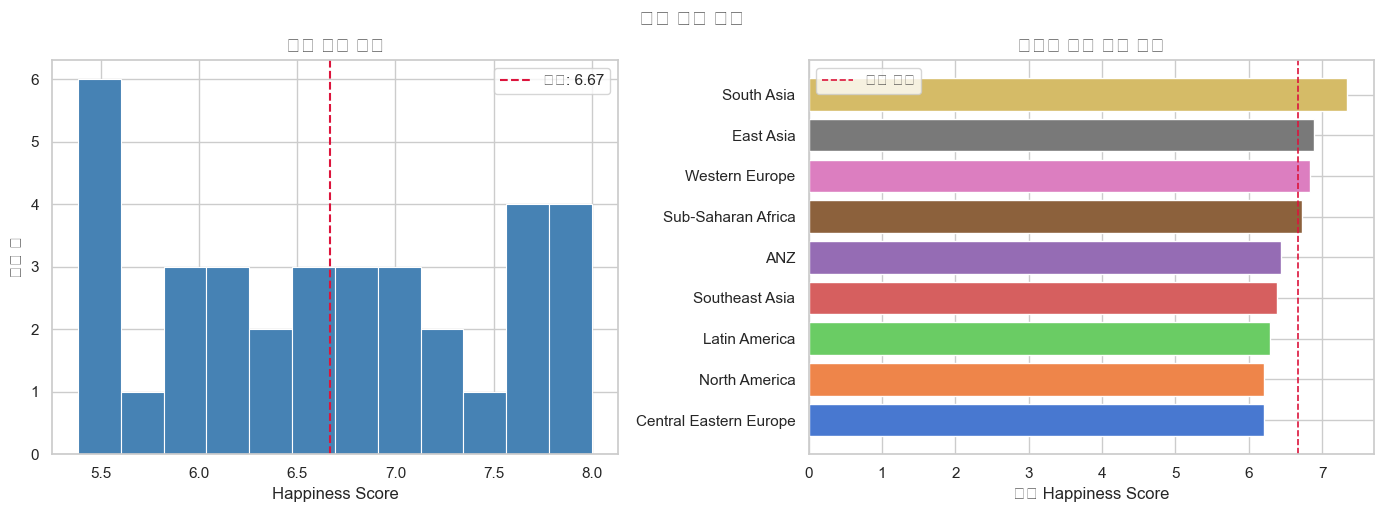

In [4]:
# 행복 점수 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Happiness_Score'], bins=12, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(df['Happiness_Score'].mean(), color='crimson', linestyle='--', linewidth=1.5, label=f"평균: {df['Happiness_Score'].mean():.2f}")
axes[0].set_title('행복 점수 분포', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Happiness Score')
axes[0].set_ylabel('국가 수')
axes[0].legend()

region_means = df.groupby('Region')['Happiness_Score'].mean().sort_values(ascending=True)
colors = sns.color_palette('muted', len(region_means))
axes[1].barh(region_means.index, region_means.values, color=colors)
axes[1].set_title('지역별 평균 행복 점수', fontsize=14, fontweight='bold')
axes[1].set_xlabel('평균 Happiness Score')
axes[1].axvline(df['Happiness_Score'].mean(), color='crimson', linestyle='--', linewidth=1.2, label='전체 평균')
axes[1].legend()

plt.tight_layout()
plt.suptitle('행복 점수 개요', y=1.02, fontsize=15, fontweight='bold')
plt.show()

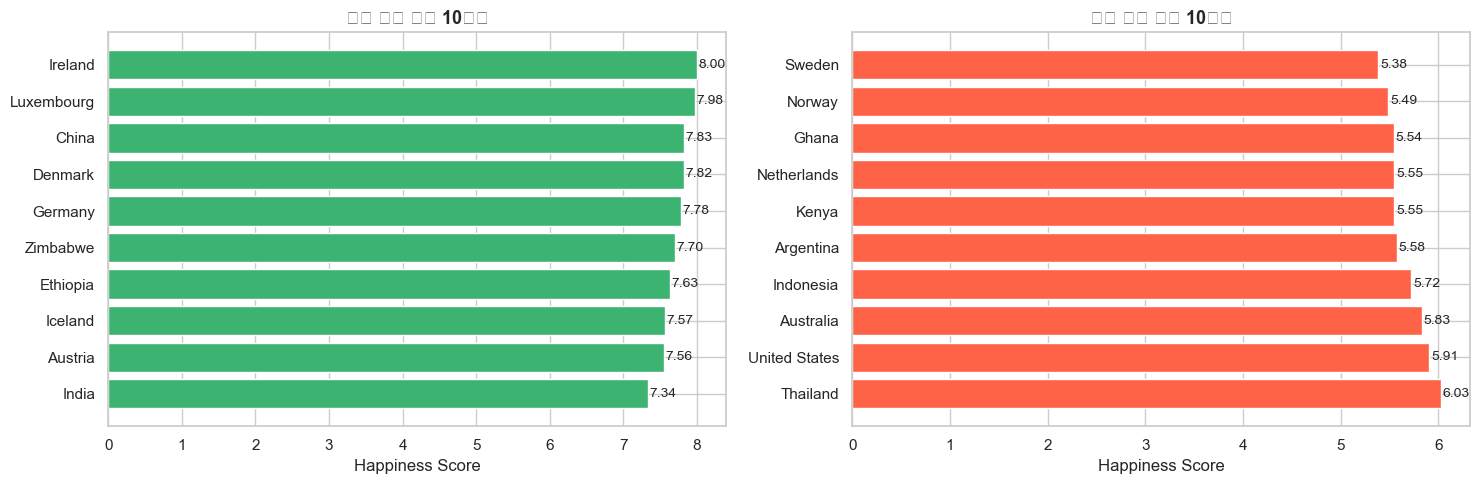

In [5]:
# 상위/하위 10개국 시각화
top10    = df.nlargest(10, 'Happiness_Score')
bottom10 = df.nsmallest(10, 'Happiness_Score')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10['Country'], top10['Happiness_Score'], color='mediumseagreen')
axes[0].set_title('행복 점수 상위 10개국', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Happiness Score')
axes[0].invert_yaxis()
for i, v in enumerate(top10['Happiness_Score']):
    axes[0].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

axes[1].barh(bottom10['Country'], bottom10['Happiness_Score'], color='tomato')
axes[1].set_title('행복 점수 하위 10개국', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Happiness Score')
axes[1].invert_yaxis()
for i, v in enumerate(bottom10['Happiness_Score']):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 3. 상관관계 분석

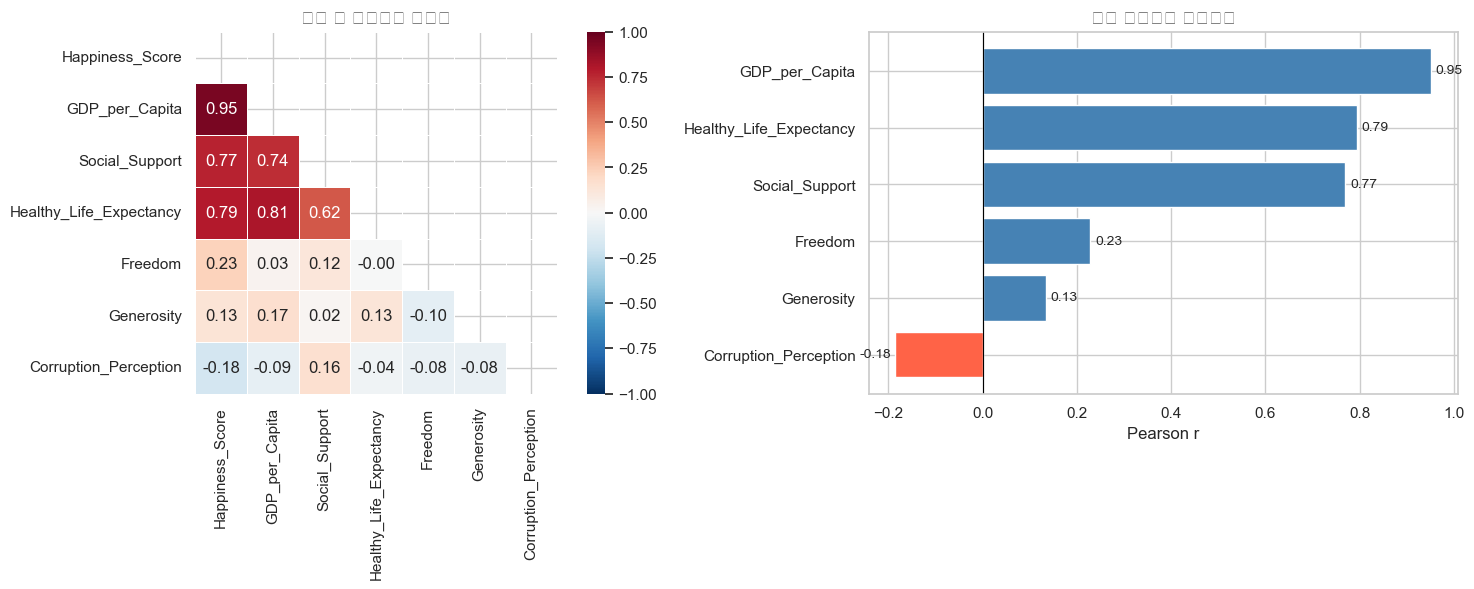


💡 인사이트:
  - GDP per capita, Social Support, Healthy Life Expectancy 가 행복 점수와 강한 양의 상관관계
  - 부패 인식(Corruption) 은 음의 상관관계
  - 관용(Generosity) 은 상대적으로 약한 상관관계


In [6]:
features = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy',
            'Freedom', 'Generosity', 'Corruption_Perception']

corr_matrix = df[['Happiness_Score'] + features].corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 히트맵
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    ax=axes[0], square=True, linewidths=0.5
)
axes[0].set_title('변수 간 상관관계 히트맵', fontsize=13, fontweight='bold')

# 행복 점수와의 개별 상관계수 막대 그래프
correlations = corr_matrix['Happiness_Score'][features].sort_values()
bar_colors = ['tomato' if c < 0 else 'steelblue' for c in correlations]
axes[1].barh(correlations.index, correlations.values, color=bar_colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('행복 점수와의 상관계수', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Pearson r')
for i, v in enumerate(correlations.values):
    axes[1].text(v + 0.01 if v >= 0 else v - 0.01, i, f'{v:.2f}',
                 va='center', ha='left' if v >= 0 else 'right', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 인사이트:')
print('  - GDP per capita, Social Support, Healthy Life Expectancy 가 행복 점수와 강한 양의 상관관계')
print('  - 부패 인식(Corruption) 은 음의 상관관계')
print('  - 관용(Generosity) 은 상대적으로 약한 상관관계')

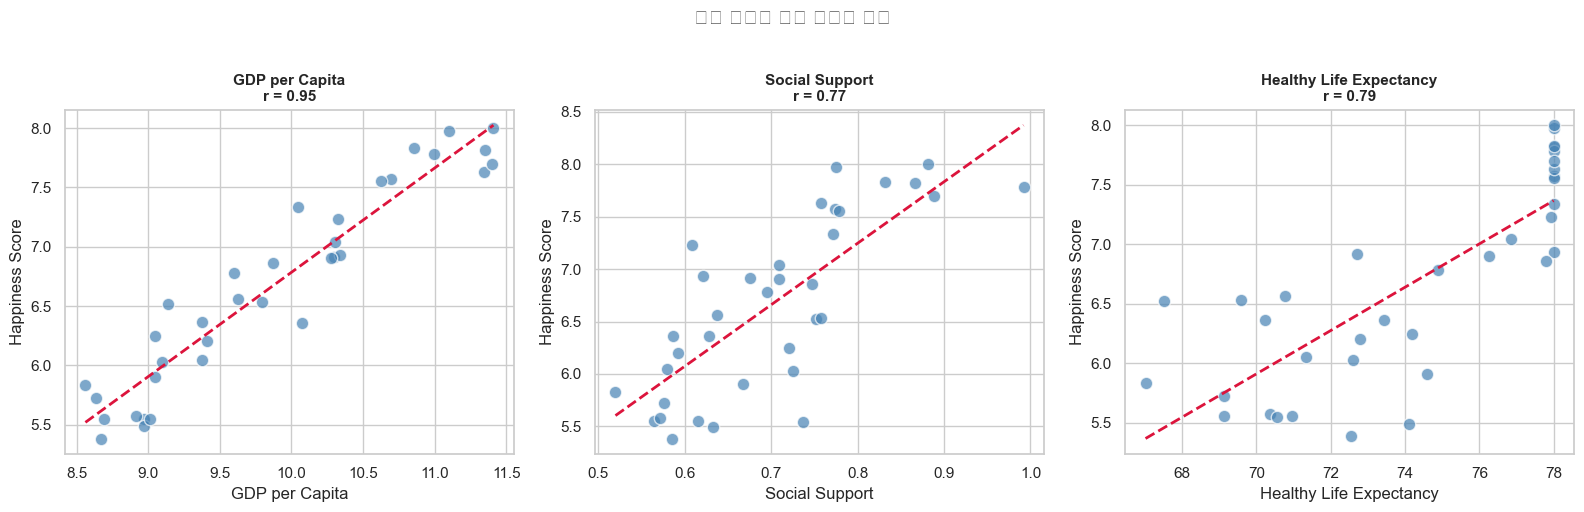

In [7]:
# 상위 3개 변수 산점도
top_features = ['GDP_per_Capita', 'Social_Support', 'Healthy_Life_Expectancy']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, feat in enumerate(top_features):
    axes[i].scatter(df[feat], df['Happiness_Score'], alpha=0.7, color='steelblue', edgecolors='white', s=80)
    # 추세선
    z = np.polyfit(df[feat], df['Happiness_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    axes[i].plot(x_line, p(x_line), color='crimson', linewidth=2, linestyle='--')
    axes[i].set_xlabel(feat.replace('_', ' '))
    axes[i].set_ylabel('Happiness Score')
    r = np.corrcoef(df[feat], df['Happiness_Score'])[0, 1]
    axes[i].set_title(f'{feat.replace("_", " ")}\nr = {r:.2f}', fontsize=11, fontweight='bold')

plt.suptitle('주요 변수와 행복 점수의 관계', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. 머신러닝 모델링

여러 회귀 모델을 비교하고, 가장 성능이 좋은 모델을 선택합니다.

In [8]:
X = df[features]
y = df['Happiness_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 정규화
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'학습셋: {X_train.shape[0]}개국  /  테스트셋: {X_test.shape[0]}개국')

학습셋: 28개국  /  테스트셋: 7개국


In [9]:
models = {
    'Linear Regression'       : LinearRegression(),
    'Ridge Regression'        : Ridge(alpha=1.0),
    'Lasso Regression'        : Lasso(alpha=0.1),
    'Random Forest'           : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'       : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    cv   = cross_val_score(model, scaler.transform(X), y, cv=5, scoring='r2').mean()

    results.append({'Model': name, 'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
                    'R²': round(r2, 4), 'CV R² (5-fold)': round(cv, 4)})

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('=== 모델 성능 비교 ===')
results_df

=== 모델 성능 비교 ===


,Model,RMSE,MAE,R²,CV R² (5-fold)
0,Ridge Regression,0.1309,0.1128,0.9012,0.8481
1,Linear Regression,0.1617,0.1452,0.8492,0.8346
2,Lasso Regression,0.2105,0.1718,0.7445,0.7929
3,Gradient Boosting,0.3162,0.2693,0.4234,0.4930
4,Random Forest,0.3328,0.2620,0.3615,0.7798


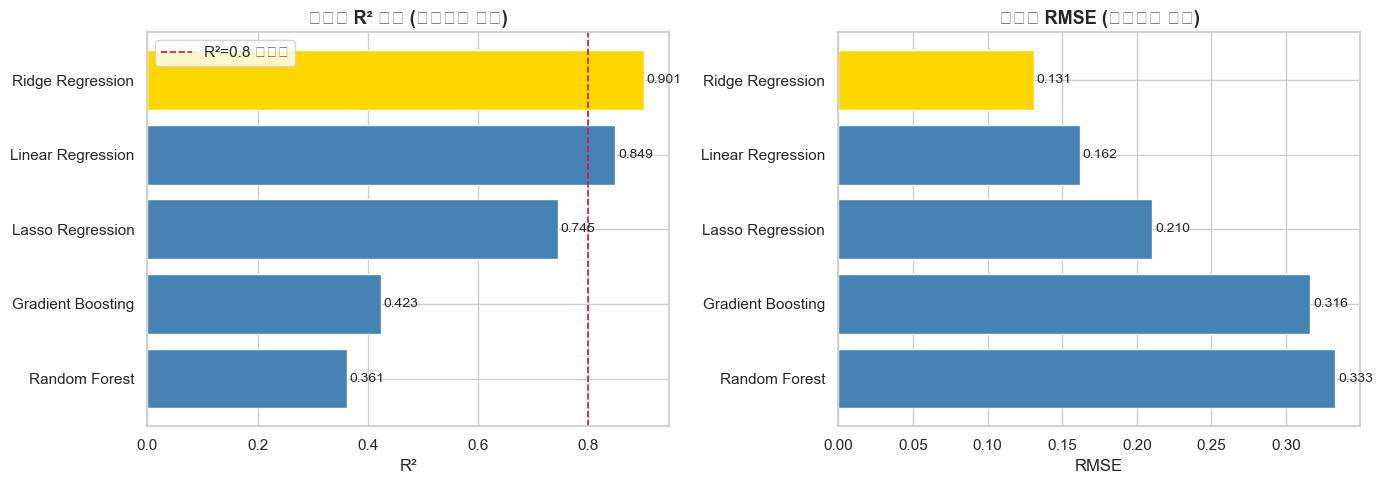

In [10]:
# 모델 성능 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Model'], results_df['R²'], color=bar_colors)
axes[0].set_title('모델별 R² 점수 (높을수록 좋음)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].axvline(0.8, color='crimson', linestyle='--', linewidth=1.2, label='R²=0.8 기준선')
axes[0].legend()
axes[0].invert_yaxis()
for i, v in enumerate(results_df['R²']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

axes[1].barh(results_df['Model'], results_df['RMSE'], color=bar_colors)
axes[1].set_title('모델별 RMSE (낮을수록 좋음)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].invert_yaxis()
for i, v in enumerate(results_df['RMSE']):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

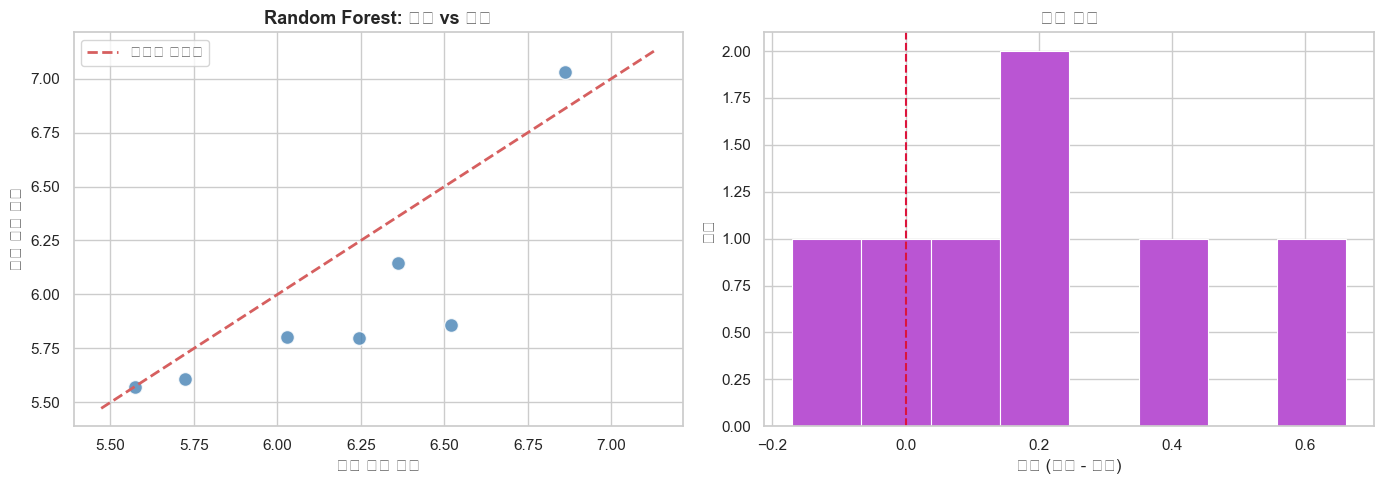

In [11]:
# 최적 모델: Random Forest
best_model = models['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 실제 vs 예측
axes[0].scatter(y_test, y_pred_best, alpha=0.8, color='steelblue', edgecolors='white', s=100)
min_val = min(y_test.min(), y_pred_best.min()) - 0.1
max_val = max(y_test.max(), y_pred_best.max()) + 0.1
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='완벽한 예측선')
axes[0].set_xlabel('실제 행복 점수')
axes[0].set_ylabel('예측 행복 점수')
axes[0].set_title('Random Forest: 실제 vs 예측', fontsize=13, fontweight='bold')
axes[0].legend()

# 잔차 분포
residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=8, color='mediumorchid', edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('잔차 (실제 - 예측)')
axes[1].set_ylabel('빈도')
axes[1].set_title('잔차 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

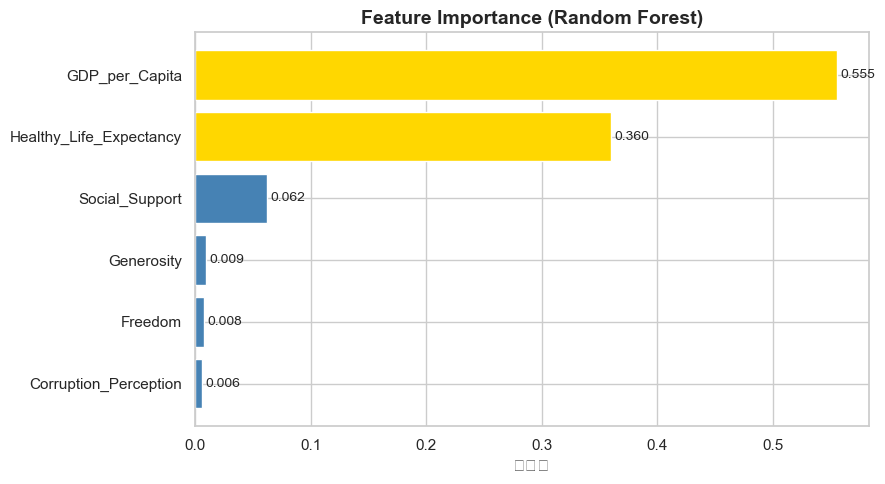


🏆 가장 중요한 변수: GDP_per_Capita


In [12]:
# Feature Importance
importances = pd.Series(
    best_model.feature_importances_, index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = ['gold' if i >= len(importances) - 2 else 'steelblue' for i in range(len(importances))]
plt.barh(importances.index, importances.values, color=colors_imp)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('중요도')
for i, v in enumerate(importances.values):
    plt.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print('\n🏆 가장 중요한 변수:', importances.idxmax())

## 5. 결론 및 인사이트

### 주요 발견

| 순위 | 요인 | 행복과의 관계 |
|------|------|-------|
| 1 | GDP per Capita | 강한 양(+) 상관 |
| 2 | Social Support | 강한 양(+) 상관 |
| 3 | Healthy Life Expectancy | 강한 양(+) 상관 |
| 4 | Freedom | 중간 양(+) 상관 |
| 5 | Corruption Perception | 음(-) 상관 |
| 6 | Generosity | 약한 상관 |

### 모델 성능
- **Random Forest**가 가장 높은 R² 및 낮은 RMSE 달성
- 6개 변수만으로도 행복 점수의 상당 부분을 설명 가능

### 한계 및 개선 방향
1. **샘플 크기**: 더 많은 국가 데이터로 일반화 성능 향상 가능
2. **시계열 분석**: 연도별 변화 트렌드 분석 추가
3. **추가 변수**: 환경 지표, 교육 수준 등 포함 검토
4. **인과 추론**: 상관관계를 넘어 인과 관계 분석 필요